In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
df = pd.read_csv("ModelOutput.csv")

In [29]:
df.columns

Index(['Unnamed: 0', 'Age', 'no_accidents', 'has_carfax', 'one_owner',
       'service_records', 'certified', 'Is_Hybrid', 'log_mileage',
       'transmission_Manual', 'std_tier_1std', 'std_tier_2std',
       'std_tier_3std', 'std_tier_Normal', 'Cylinders', 'Body_Type', 'Make',
       'price', 'Model', 'Year', 'mileage', 'y_pred', 'predicted_price',
       'error', 'abs_error', 'pct_error'],
      dtype='object')

In [ ]:
RMSE = 6859.444685
OverRMSE = df[(df["abs_error"] >=RMSE)]

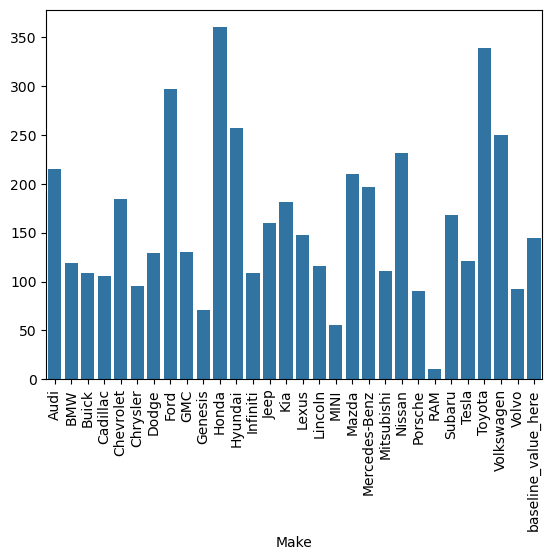

In [31]:
x=df.groupby(["Make"]).count()["Model"].index
y=df.groupby(["Make"]).count()["Model"].values
sns.barplot(x=x,y=y)
plt.xticks(rotation = 90)
plt.show()

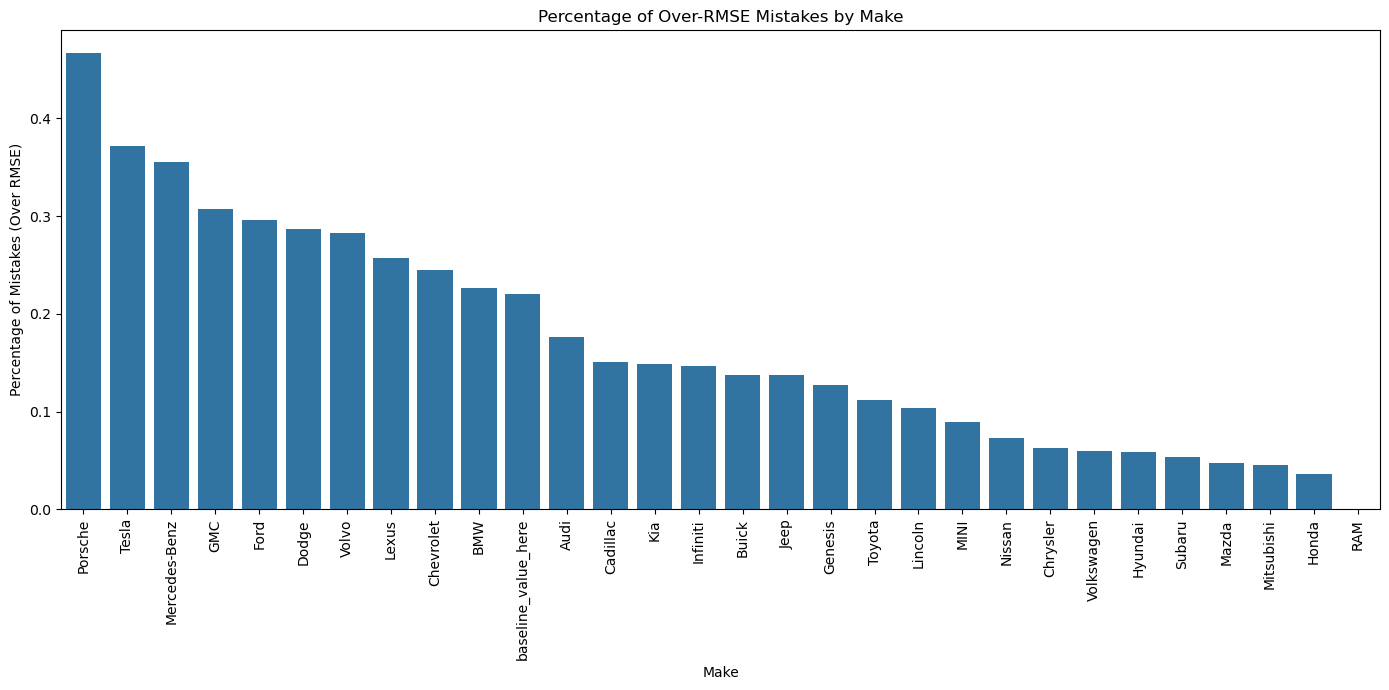

In [32]:

NumberOfModels = pd.DataFrame(df.groupby(["Make"]).count()["Model"])
NumberOfModelsOverRMSEMistakes = pd.DataFrame(OverRMSE.groupby(["Make"]).count()["Model"])

PercentageOfMistake = NumberOfModelsOverRMSEMistakes["Model"] / NumberOfModels["Model"]

# Sort the Series itself (keeps label-value pairs together), not just the index
PercentageOfMistake = PercentageOfMistake.sort_values(ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(x=PercentageOfMistake.index, y=PercentageOfMistake.values)
plt.xticks(rotation=90)
plt.ylabel("Percentage of Mistakes (Over RMSE)")
plt.xlabel("Make")
plt.title("Percentage of Over-RMSE Mistakes by Make")
plt.tight_layout()
plt.show()

In [33]:
import sys
if 'residual_dashboard' in sys.modules:
    del sys.modules['residual_dashboard']
from residual_dashboard import build_residual_dashboard

fig = build_residual_dashboard(
    df,
    x_options=["Cylinders", "Model", "mileage", "Body_Type", "Year"],
    error_col="abs_error"
)
fig.show()

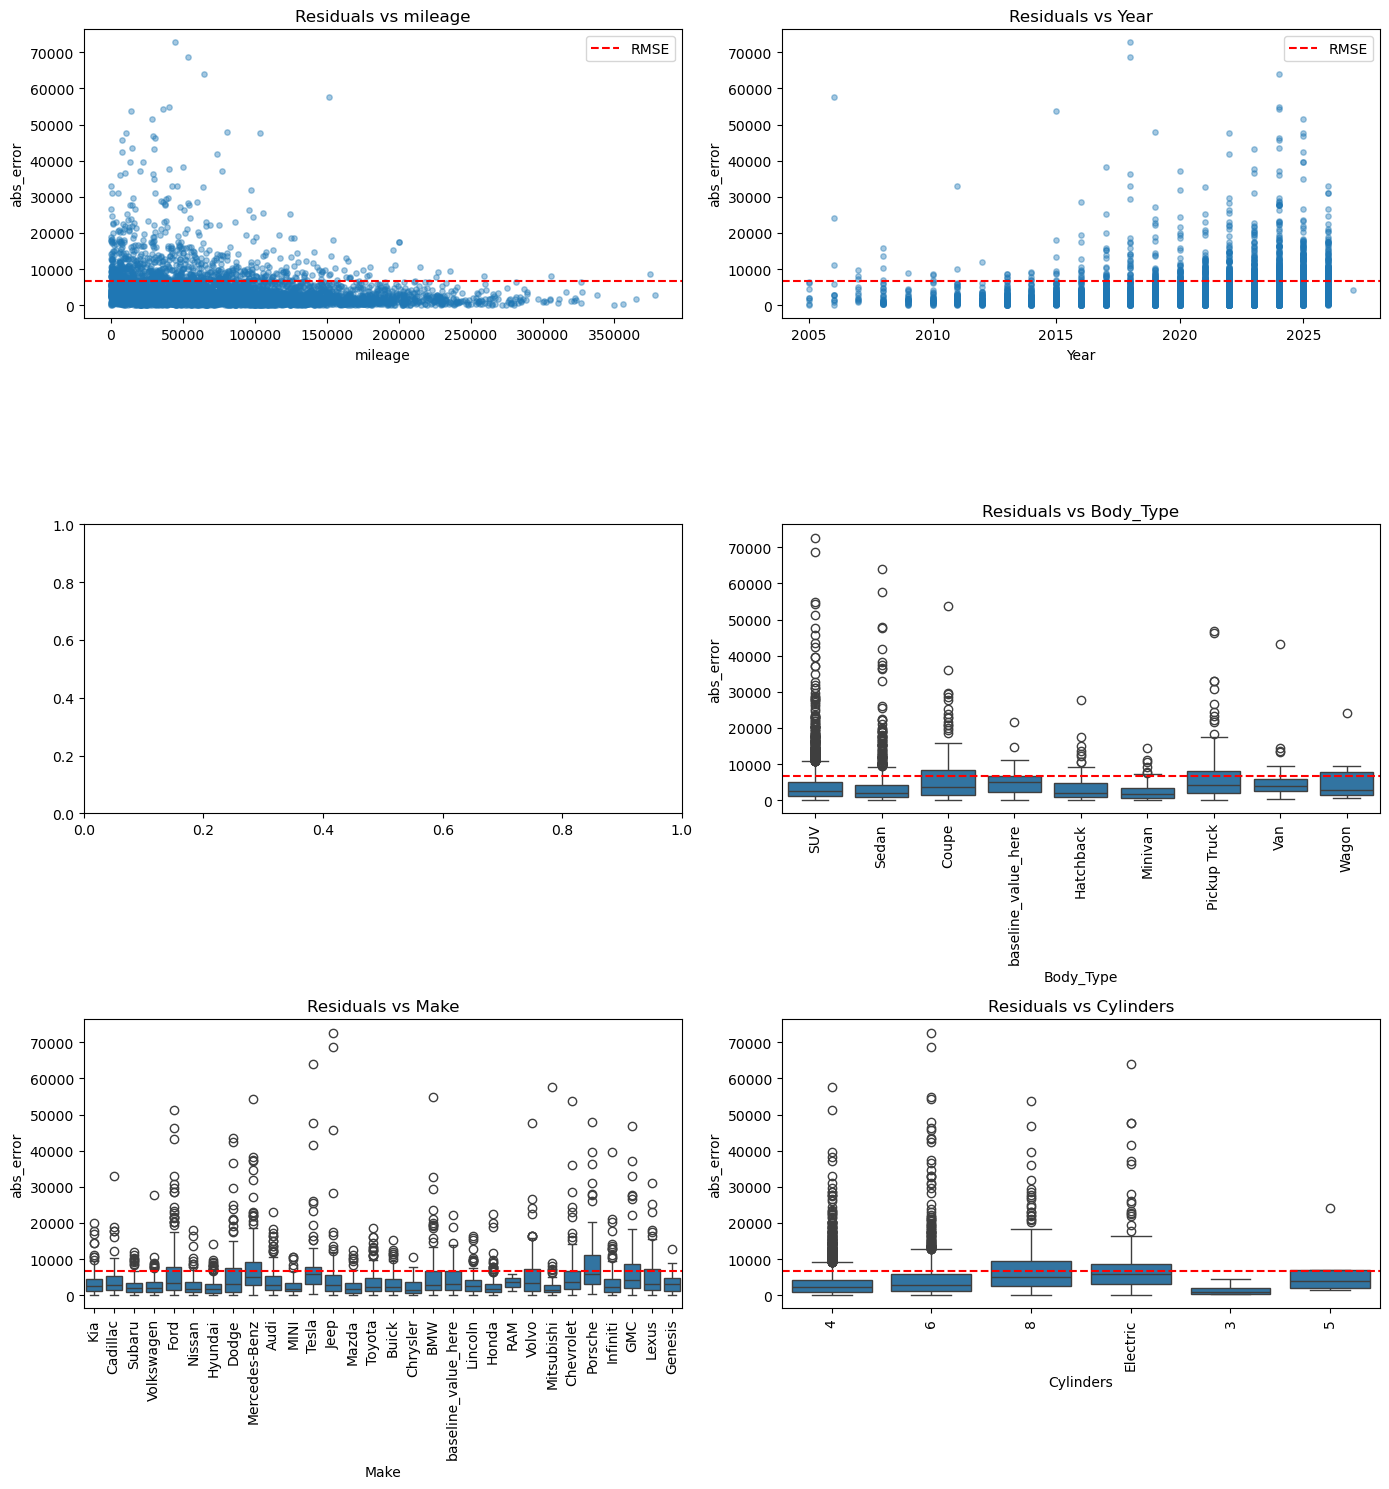

In [34]:

numeric_features = ["mileage", "Year"]
categorical_features = ["Body_Type", "Make","Cylinders"]

n_features = len(numeric_features) + len(categorical_features)
fig, axes = plt.subplots(nrows=(n_features + 1) // 2, ncols=2, figsize=(14, 5 * ((n_features + 1) // 2)))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    axes[i].scatter(df[feature], df["abs_error"], alpha=0.4, s=15)
    axes[i].axhline(RMSE, color="red", linestyle="--", label="RMSE")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("abs_error")
    axes[i].set_title(f"Residuals vs {feature}")
    axes[i].legend()

for j, feature in enumerate(categorical_features):
    idx = len(categorical_features) + j
    sns.boxplot(data=df, x=feature, y="abs_error", ax=axes[idx])
    axes[idx].axhline(RMSE, color="red", linestyle="--")
    axes[idx].set_title(f"Residuals vs {feature}")
    axes[idx].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [35]:
#My Worst Error:
# Define "worst" as top 10% by absolute error - adjust threshold as needed
threshold = df["abs_error"].quantile(0.90)
worst = df[df["abs_error"] >= threshold]
rest = df[df["abs_error"] < threshold]

print(f"Worst-error rows: {len(worst)} ({len(worst)/len(df)*100:.1f}% of data)")
print()

# Compare numeric features
for feature in numeric_features:
    print(f"--- {feature} ---")
    print(f"Worst-error mean: {worst[feature].mean():.1f}   |   Rest mean: {rest[feature].mean():.1f}")
    print()

# Compare categorical features (which categories are over-represented in the worst-error group?)
for feature in categorical_features:
    worst_pct = worst[feature].value_counts(normalize=True) * 100
    rest_pct = rest[feature].value_counts(normalize=True) * 100
    comparison = pd.DataFrame({"worst_%": worst_pct, "rest_%": rest_pct}).fillna(0)
    comparison["difference"] = comparison["worst_%"] - comparison["rest_%"]
    print(f"--- {feature} (sorted by biggest over-representation in worst-error group) ---")
    print(comparison.sort_values("difference", ascending=False).head(10))
    print()

Worst-error rows: 481 (10.0% of data)

--- mileage ---
Worst-error mean: 45903.4   |   Rest mean: 86729.0

--- Year ---
Worst-error mean: 2022.6   |   Rest mean: 2020.7

--- Body_Type (sorted by biggest over-representation in worst-error group) ---
                       worst_%     rest_%  difference
Body_Type                                            
Pickup Truck         11.434511   4.945690    6.488822
Coupe                 7.068607   2.542177    4.526430
Wagon                 0.623701   0.277328    0.346372
Van                   1.039501   0.716432    0.323069
baseline_value_here   0.831601   0.785764    0.045837
Hatchback             1.871102   2.750173   -0.879071
Minivan               0.831601   4.229258   -3.397657
Sedan                18.295218  21.862722   -3.567504
SUV                  58.004158  61.890455   -3.886297

--- Make (sorted by biggest over-representation in worst-error group) ---
                 worst_%    rest_%  difference
Make                               